# SGD_Ex.ipynb — Demo Stochastic Gradient Descent trên Titanic

Notebook này demo **Stochastic Gradient Descent (SGD)** trên dataset Titanic thật.

Mục tiêu: dùng **Logistic Regression tự viết bằng NumPy + SGD** để dự đoán hành khách có sống sót hay không.

Bài này tập trung vào bản chất:
- dữ liệu thật có missing values
- cần xử lý categorical variables
- cần chuẩn hóa dữ liệu
- tự viết vòng lặp SGD
- theo dõi loss qua từng epoch
- đánh giá model
- so sánh nhanh với `SGDClassifier` của sklearn


## 1. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)


## 2. Load dataset Titanic thật

Ta sẽ thử load bằng `seaborn`. Nếu máy bạn chưa có cache dataset, notebook sẽ tự fallback sang link CSV public.

Target của bài này là:

```python
survived
```

Trong đó:
- `1` = sống sót
- `0` = không sống sót


In [2]:
try:
    df = pd.read_csv("../data/titanic/Titanic-Dataset.csv")
    print("Loaded Titanic dataset from local file.")
except Exception as e:
    print("Cannot load local file, fallback to public CSV.")
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
    df = pd.read_csv(url)

df.head()


Loaded Titanic dataset from local file.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape, df.columns.tolist()

((891, 12),
 ['PassengerId',
  'Survived',
  'Pclass',
  'Name',
  'Sex',
  'Age',
  'SibSp',
  'Parch',
  'Ticket',
  'Fare',
  'Cabin',
  'Embarked'])

## 3. Chọn features đơn giản

Ta chọn vài biến dễ hiểu:

| Feature | Ý nghĩa |
|---|---|
| `pclass` | hạng vé |
| `sex` | giới tính |
| `age` | tuổi |
| `sibsp` | số anh/chị/em/vợ/chồng đi cùng |
| `parch` | số cha/mẹ/con đi cùng |
| `fare` | giá vé |
| `embarked` | cảng lên tàu |

Target là:

```python
survived
```


In [4]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target = "Survived"

data = df[features + [target]].copy()
data.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


## 4. Kiểm tra missing values

Dataset thật thường không sạch hoàn toàn. Titanic có một số cột bị thiếu dữ liệu, đặc biệt là `age` và `embarked`.


In [5]:
data.isna().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
dtype: int64

## 5. Làm sạch dữ liệu

Cách xử lý đơn giản:

- `age`: điền bằng median
- `embarked`: điền bằng mode
- `fare`: nếu thiếu thì điền bằng median


In [6]:
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Fare"] = data["Fare"].fillna(data["Fare"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

data.isna().sum()


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
dtype: int64

## 6. Encode categorical variables

Máy học không hiểu chữ như `male`, `female`, `S`, `C`, `Q`.

Ta cần chuyển chúng thành số.

- `sex`: dùng map `male = 0`, `female = 1`
- `embarked`: dùng one-hot encoding


In [7]:
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})

data = pd.get_dummies(data, columns=["Embarked"], drop_first=True)

data.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Survived,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,0,False,True
1,1,1,38.0,1,0,71.2833,1,False,False
2,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,35.0,1,0,53.1000,1,False,True
4,3,0,35.0,0,0,8.0500,0,False,True


## 7. Tách X và y

- `X`: các biến đầu vào
- `y`: nhãn cần dự đoán


In [8]:
X = data.drop(columns=[target]).values.astype(float)
y = data[target].values.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (891, 8)
y shape: (891,)


## 8. Train/Test split

Ta chia dữ liệu thành:

- train set: dùng để học
- test set: dùng để kiểm tra model


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (712, 8)
Test: (179, 8)


## 9. Chuẩn hóa dữ liệu

SGD rất nhạy với scale.

Ví dụ:
- `fare` có thể lớn hơn 100
- `sex` chỉ là 0 hoặc 1

Nếu không chuẩn hóa, feature có giá trị lớn dễ làm gradient bị lệch.

Ta dùng `StandardScaler` để đưa dữ liệu về dạng gần như:

- mean ≈ 0
- std ≈ 1


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]


array([[ 0.82956755, -0.74242727, -0.11207776, -0.46508428, -0.46618317,
         0.5138115 , -0.28933346,  0.61197825],
       [-0.37094484, -0.74242727, -0.11207776, -0.46508428, -0.46618317,
        -0.66256323, -0.28933346,  0.61197825],
       [-1.57145722, -0.74242727, -0.11207776, -0.46508428, -0.46618317,
         3.95539858, -0.28933346,  0.61197825],
       [ 0.82956755,  1.34693328, -0.87980748, -0.46508428,  0.72778236,
        -0.46787435, -0.28933346,  0.61197825],
       [-0.37094484,  1.34693328,  0.11824116,  0.47833454,  0.72778236,
        -0.11597681, -0.28933346,  0.61197825]])

## 10. Logistic Regression dùng Sigmoid

Vì Titanic là bài toán classification 0/1, ta không dùng Linear Regression trực tiếp.

Ta dùng Logistic Regression:

$$
z = Xw + b
$$

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ý nghĩa:

- output gần 1 → model dự đoán sống sót
- output gần 0 → model dự đoán không sống sót


In [11]:
def sigmoid(z):
    # Clip để tránh overflow khi z quá lớn hoặc quá nhỏ
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


## 11. Binary Cross Entropy Loss

Với bài toán 0/1 classification, ta dùng Binary Cross Entropy:

$$
Loss = -[y\log(\hat{y}) + (1-y)\log(1-\hat{y})]
$$

Nếu model dự đoán sai với độ tự tin cao, loss sẽ rất lớn.


In [12]:
def binary_cross_entropy(y_true, y_prob):
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))


## 12. Viết Logistic Regression bằng SGD từ đầu

Ý tưởng SGD:

Với mỗi epoch:
1. shuffle dữ liệu train
2. lấy từng passenger một
3. dự đoán xác suất sống sót
4. tính error
5. update `w` và `b`

Với Logistic Regression + BCE, gradient rất gọn:

$$
error = \hat{y} - y
$$

$$
dw = error \times x_i
$$

$$
db = error
$$

Cập nhật:

$$
w = w - \alpha dw
$$

$$
b = b - \alpha db
$$


In [13]:
def train_logistic_regression_sgd(X, y, lr=0.01, epochs=100):
    n_samples, n_features = X.shape

    # Khởi tạo weight và bias
    w = np.zeros(n_features)
    b = 0.0

    loss_history = []

    for epoch in range(epochs):
        # Shuffle dữ liệu mỗi epoch để SGD học ổn hơn
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # SGD: update từng sample
        for xi, yi in zip(X_shuffled, y_shuffled):
            z = np.dot(xi, w) + b
            y_pred = sigmoid(z)

            error = y_pred - yi

            dw = error * xi
            db = error

            w = w - lr * dw
            b = b - lr * db

        # Tính loss sau mỗi epoch
        y_prob_all = sigmoid(np.dot(X, w) + b)
        loss = binary_cross_entropy(y, y_prob_all)
        loss_history.append(loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {loss:.4f}")

    return w, b, loss_history


## 13. Train model

Bạn có thể thử thay đổi:
- `lr`
- `epochs`

để xem loss thay đổi như thế nào.


In [14]:
w, b, loss_history = train_logistic_regression_sgd(
    X_train_scaled,
    y_train,
    lr=0.01,
    epochs=100
)

print("\nFinal weights:", w)
print("Final bias:", b)


Epoch  10 | Loss: 0.4366
Epoch  20 | Loss: 0.4364
Epoch  30 | Loss: 0.4364
Epoch  40 | Loss: 0.4367
Epoch  50 | Loss: 0.4371
Epoch  60 | Loss: 0.4366
Epoch  70 | Loss: 0.4366
Epoch  80 | Loss: 0.4368
Epoch  90 | Loss: 0.4368
Epoch 100 | Loss: 0.4365

Final weights: [-0.94464274  1.2994337  -0.5221341  -0.26737968 -0.11054288  0.07960137
  0.09897986 -0.19237952]
Final bias: -0.665847400916513


## 14. Vẽ loss qua epochs

Nếu SGD học tốt, loss thường sẽ giảm dần.

Vì SGD update từng sample nên đường loss có thể không hoàn toàn mượt.


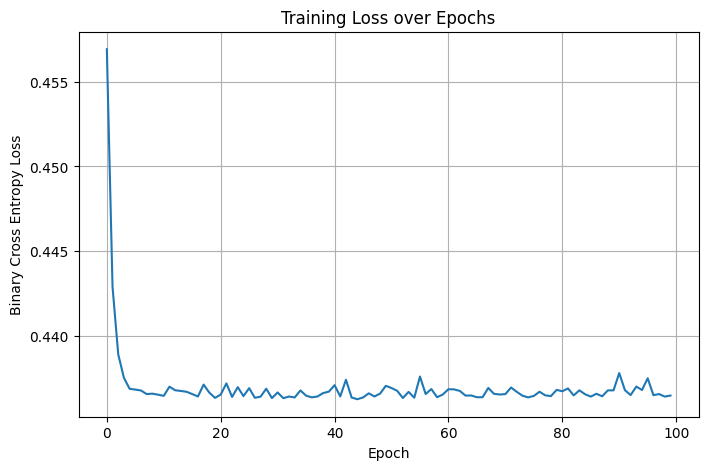

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()


## 15. Dự đoán trên test set

Model output ra xác suất.

Ta chuyển xác suất thành class:

- nếu probability >= 0.5 → dự đoán 1
- nếu probability < 0.5 → dự đoán 0


In [16]:
def predict_proba(X, w, b):
    return sigmoid(np.dot(X, w) + b)

def predict_class(X, w, b, threshold=0.5):
    probs = predict_proba(X, w, b)
    return (probs >= threshold).astype(int)

y_test_prob = predict_proba(X_test_scaled, w, b)
y_test_pred = predict_class(X_test_scaled, w, b)

print("First 10 probabilities:")
print(y_test_prob[:10])

print("\nFirst 10 predicted classes:")
print(y_test_pred[:10])


First 10 probabilities:
[0.06398024 0.04206342 0.15520427 0.03288933 0.71347407 0.44817599
 0.76332034 0.32119769 0.32717689 0.15517874]

First 10 predicted classes:
[0 0 0 0 1 0 1 0 0 0]


## 16. Đánh giá model

In [17]:
acc = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)

print("Accuracy:", acc)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Accuracy: 0.8044692737430168

Confusion Matrix:
[[98 12]
 [23 46]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.89      0.85       110
         1.0       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## 17. Hiểu Confusion Matrix

Confusion matrix thường có dạng:

```text
[[TN, FP],
 [FN, TP]]
```

Ý nghĩa:

- TN: thật là không sống sót, model đoán không sống sót
- FP: thật là không sống sót, model đoán sống sót
- FN: thật là sống sót, model đoán không sống sót
- TP: thật là sống sót, model đoán sống sót


## 18. So sánh với SGDClassifier của sklearn

Bản tự viết giúp hiểu bản chất.

Bản sklearn dùng trong thực tế vì:
- tối ưu hơn
- ổn định hơn
- nhiều option hơn


In [18]:
from sklearn.linear_model import SGDClassifier

sk_model = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.01,
    max_iter=1000,
    random_state=42
)

sk_model.fit(X_train_scaled, y_train)

sk_pred = sk_model.predict(X_test_scaled)

print("Sklearn SGDClassifier Accuracy:", accuracy_score(y_test, sk_pred))
print("\nClassification Report:")
print(classification_report(y_test, sk_pred))


Sklearn SGDClassifier Accuracy: 0.8044692737430168

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.89      0.85       110
         1.0       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## 19. Kết luận

Trong notebook này, bạn đã thấy SGD trên dataset thật:

1. Titanic là bài toán classification 0/1.
2. Ta dùng Logistic Regression, không dùng Linear Regression.
3. SGD update weight theo từng passenger.
4. Mỗi epoch là một lần model đi qua toàn bộ train set.
5. Loss giảm dần nghĩa là model đang học.
6. Bản tự viết bằng NumPy giúp hiểu bản chất.
7. Bản sklearn phù hợp hơn khi dùng thực tế.

Cốt lõi của SGD vẫn là:

> Dự đoán → tính lỗi → tính gradient → cập nhật weight → lặp lại nhiều lần.
